# **1. 주택 임대료 예측 데이터셋**
- House Rent Prediction Dataset은 주택 임대료를 예측하기 위한 목적으로 사용되는 데이터셋이다.
- 이 데이터셋은 주로 머신러닝 및 데이터 분석 프로젝트에서 사용되며, 
- 주택의 다양한 특성과 위치 정보를 기반으로 임대료를 예측하는 모델을 학습하는 데 활용된다.

# **2. 데이터셋 컬럼**
- **Rent**: 주택(아파트/플랫)의 월 임대료를 나타냅니다. (Label)
- **BHK**: 주택에 포함된 침실, 거실, 주방의 총 개수를 의미합니다.
- **Size**: 주택(아파트/플랫)의 면적을 평방피트(Square Feet)로 나타냅니다.
- **Floor**: 주택이 위치한 층수와 건물의 총 층수를 나타냅니다. (예: 2층 중 1층, 5층 중 3층 등)
- **Area Type**: 주택의 면적이 어떤 방식으로 계산되었는지를 나타냅니다. (예: 전체 면적, 실사용 면적, 건축 면적 등)
- **Area Locality**: 주택(아파트/플랫)이 위치한 구체적인 지역이나 동네 정보를 나타냅니다.
- **City**: 주택(아파트/플랫)이 위치한 도시를 나타냅니다.
- **Furnishing Status**: 주택이 가구가 완비되었는지(Furnished), 부분적으로 갖추어졌는지(Semi-Furnished), 아니면 비어 있는지(Unfurnished)를 나타냅니다.
- **Tenant Preferred**: 집주인 또는 중개인이 선호하는 임차인 유형을 나타냅니다. (예: 가족, 싱글, 직장인 등)
- **Bathroom**: 주택에 있는 욕실의 개수를 나타냅니다.
- **Point of Contact**: 주택(아파트/플랫)에 대한 추가 정보를 얻기 위해 연락해야 할 담당자나 중개인의 정보를 나타냅니다.

# **3. 데이터셋 전처리**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
rent_df = pd.read_csv("./data/House_Rent_Dataset.csv")
rent_df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
rent_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [4]:
# 통계치
rent_df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [5]:
# 소수점 2자리까지 표기
round(rent_df.describe(), 2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [6]:
# BHK 시리즈
rent_df['BHK']

0       2
1       2
2       2
3       2
4       2
       ..
4741    2
4742    3
4743    3
4744    3
4745    2
Name: BHK, Length: 4746, dtype: int64

In [7]:
import matplotlib.pyplot as plt

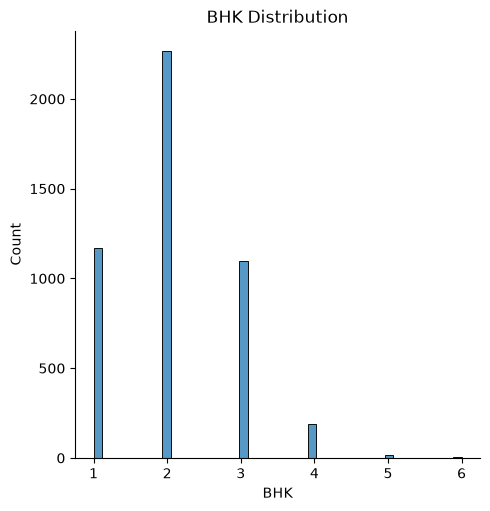

In [8]:
sns.displot(rent_df['BHK'])
plt.title('BHK Distribution')
plt.show()

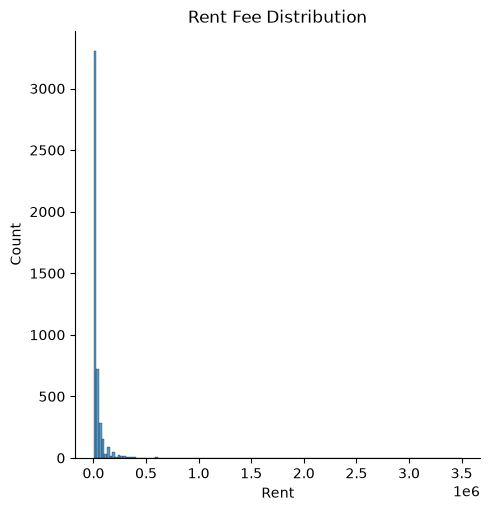

In [9]:
sns.displot(rent_df['Rent'])
plt.title('Rent Fee Distribution')
plt.show()

In [10]:
# Proves that the maximum price is 3.5 (Which is not visible on the plot.)
rent_df['Rent'].sort_values(ascending=False)

1837    3500000
1001    1200000
827     1000000
1329     850000
1459     700000
         ...   
506        2200
2475       2000
471        1800
285        1500
4076       1200
Name: Rent, Length: 4746, dtype: int64

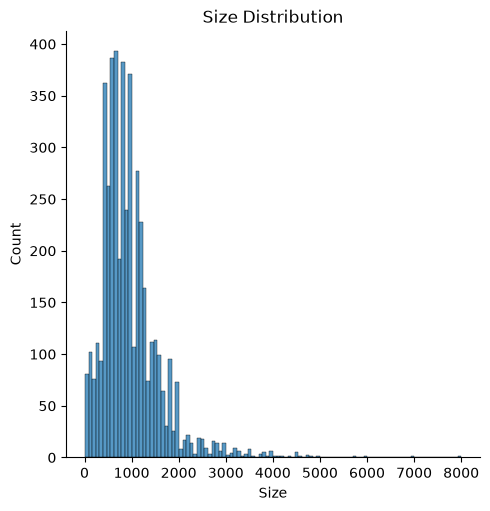

In [11]:
sns.displot(rent_df['Size'])
plt.title('Size Distribution')
plt.show()

### boxplot
- 데이터의 중앙값, 사분위수, 이상치 등을 시각적으로 표현하는 통계 그래프
- 주로 데이터 분포와 이상치를 빠르게 파악하기 위해 사용됨
1. Q1 (제1사분위수, 25%): 하위 25%에 해당하는 값
2. Q2 (중앙값, Median): 데이터를 크기 순으로 정렬했을 때 중간에 위치한 값
3. Q3 (제3사분위수, 75%): 상위 25%에 해당하는 값
4. IQR (Interquartile Range, 사분위 범위): Q3 - Q1, IQR은 데이터의 중간 50% 범위를 의미한다.
5. Minimum: Q1 - 1.5 x IQR 이하에 속하지 않는 가장 작은 값
6. Maximum: Q3 + 1.5 x IQR 이하에 속하지 않는 가장 큰 값
7. Outlier (이상치): 일반적인 데이터 분포를 벗어난 값
    - Lower Bound = Q1 - 1.5xIQR 
    - Upper Bound = Q3 + 1.5xIQR
    - IQR 기준으로 이상치를 정의하기 때문에 모든 상황에 완벽하기 않을 수 있다.

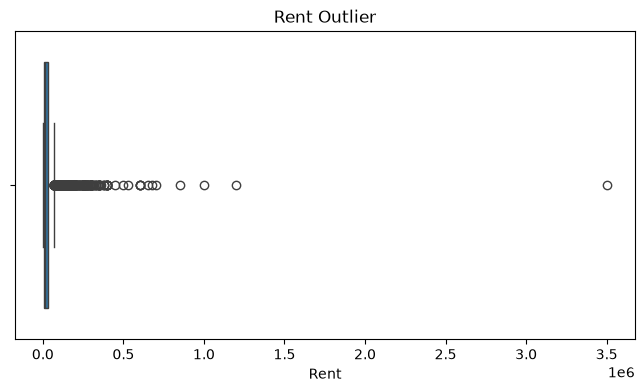

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=rent_df['Rent'])
plt.title('Rent Outlier')
plt.show()

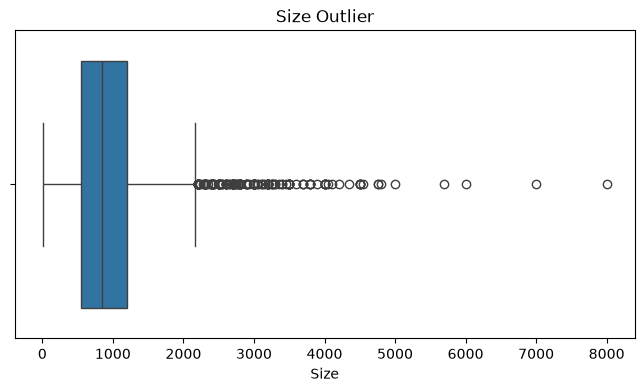

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=rent_df['Size'])
plt.title('Size Outlier')
plt.show()

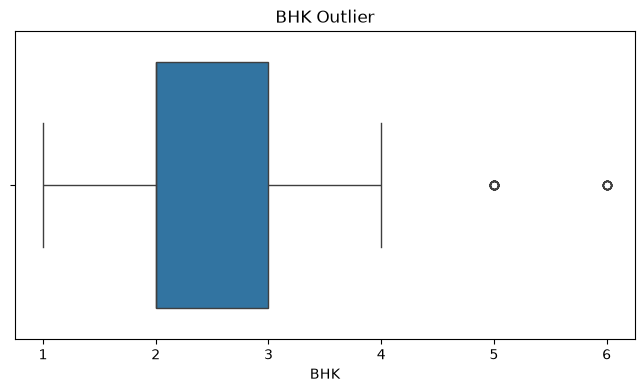

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=rent_df['BHK'])
plt.title('BHK Outlier')
plt.show()

In [15]:
# Check missing values
rent_df.isna().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [16]:
rent_df.isna().mean()

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

In [17]:
# To train models, data types have to be numbers, not string
rent_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [18]:
# Check types
rent_df['Area Type'].unique()

<StringArray>
['Super Area', 'Carpet Area', 'Built Area']
Length: 3, dtype: str

In [19]:
# Check number of types
rent_df['Area Type'].nunique()

3

In [20]:
# Print number of unique types for each column
for i in ['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']:
    print(i, rent_df[i].nunique())

Posted On 81
Floor 480
Area Type 3
Area Locality 2235
City 6
Furnishing Status 3
Tenant Preferred 3
Point of Contact 3


In [21]:
rent_df.select_dtypes(include="str").columns

Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='str')

In [22]:
obj_cols = rent_df.select_dtypes(include="str").columns
for col in obj_cols:
    print(col, rent_df[col].nunique())

Posted On 81
Floor 480
Area Type 3
Area Locality 2235
City 6
Furnishing Status 3
Tenant Preferred 3
Point of Contact 3


In [23]:
# 문자열 컬럼이라고 무조건 삭제하지 않고, 숫자로 의미 있게 변환할 수 있는 컬럼은 가공함
# Posted On
rent_df['Posted On'] = pd.to_datetime(rent_df['Posted On'])
rent_df['Posted_Year'] = rent_df['Posted On'].dt.year
rent_df['Posted_Month'] = rent_df['Posted On'].dt.month
rent_df['Posted_DayOfWeek'] = rent_df['Posted On'].dt.dayofweek

In [24]:
# Floor
# 'Ground oft of 2', '3 out of 5' 문자열
# extract: 문자열에서 특정 패턴을 찾아서 뽑아내는 함수
# 현재층 out of 전체층
# r': Raw string(원시 문자열)
# (?P<Total_Floors>\d+) 숫자를 찾고 그 결과 컬럼 이름을 name으로 붙임
floor_pattern = (
    r'(?P<Current_Floor>Upper Basement|Lower Basement|Ground|Upper|Lower|Basement|\d+)'
    r'\s+out of\s+'
    r'(?P<Total_Floors>\d+)'
)

floor_split = rent_df['Floor'].astype(str).str.extract(floor_pattern)

floor_map = {
    'Ground' : 0,
    'Lower' : 0,
    'Basement' : -1,
    'Upper' : np.nan,
    'Upper Basement' : -1,
    'Lower Basement' : -1
}

# 정규식으로 분리되지 않은 원본값 확인
unmatched_floor_values = rent_df.loc[floor_split['Current_Floor'].isna(), 'Floor'].value_counts()
unmatched_floor_values

Floor
1         2
3         1
Ground    1
Name: count, dtype: int64

In [25]:
# replace 후 바로 astype(float)을 쓰면 문자열이 남아 있을 때 에러 날 수 있음
# pd.to_numeric(errors='coerce')로 안전하게 숫자 변환
rent_df['Current_Floor'] = floor_split['Current_Floor'].replace(floor_map)
rent_df['Current_Floor'] = pd.to_numeric(rent_df['Current_Floor'], errors='coerce')
rent_df['Total_Floors'] = pd.to_numeric(floor_split['Total_Floors'], errors='coerce')

In [26]:
# Upper는 정확한 현재 층을 알 수 없으므로 Total_Floors 값으로 보정
# 예: Upper out of 4 -> 4층 정도로 간주
upper_mask = floor_split['Current_Floor'].eq('Upper') & rent_df['Current_Floor'].isna()
rent_df.loc[upper_mask, 'Current_Floor'] = rent_df.loc[upper_mask, 'Total_Floors']

# 추가 파생변수: 전체 층수 대비 현재 층의 위치
rent_df['Floor_Ratio'] = rent_df['Current_Floor'] / rent_df['Total_Floors']
rent_df['Floor_Ratio'] = rent_df['Floor_Ratio'].replace([np.inf, -np.inf], np.nan)

rent_df[['Floor', 'Current_Floor', 'Total_Floors', 'Floor_Ratio']].head() 

,Floor,Current_Floor,Total_Floors,Floor_Ratio
0,Ground out of 2,0.0,2.0,0.000000
1,1 out of 3,1.0,3.0,0.333333
2,1 out of 3,1.0,3.0,0.333333
3,1 out of 2,1.0,2.0,0.500000
4,1 out of 2,1.0,2.0,0.500000


In [27]:
# Area Locality는 지역 정보이므로 삭제하지 않고 범주형 변수로 남김
# 전체 데이터에서 빈도 인코딩을 먼저 하면 train/test 정보가 섞이는 데이터 누수 가능성이 있음
# Pipeline 내부의 OneHotEncoder가 학습 데이터 기준으로만 인코딩하도록 처리

In [28]:
rent_df.drop(['Floor', 'Posted On'], axis=1, inplace=True)

In [29]:
# 전처리 + 모델링을 위해 X, y를 먼저 분리
X = rent_df.drop('Rent', axis=1)
y = rent_df['Rent']

In [30]:
# 숫자 컬럼과 문자 컬럼을 분리
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['str', 'category', 'object', 'bool']).columns.tolist()

print('Numeric Columns: ', numeric_features)
print('Categorical Columns: ', categorical_features)
print('X 결측치 개수: ', X.isna().sum().sum())

Numeric Columns:  ['BHK', 'Size', 'Bathroom', 'Current_Floor', 'Total_Floors', 'Floor_Ratio']
Categorical Columns:  ['Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']
X 결측치 개수:  12


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 2026)

### Pipeline
- 데이터 전처리 + 모델 학습을 자동으로 연결한 작업 흐름

```
pipe = Pipeline([
    ('이름1', 작업1),
    ('이름2', 작업2),
    ...
])
```

### 머신러닝 작업 순서
1. 결측치 처리
2. 문자열 숫자화(라벨 인코딩)
3. 스케일링(데이터 크기 조정)
4. 모델 학습

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [34]:
# 테스트 데이터에 학습 떄 못 본 지역/도시/옵션이 나와도 데러가 나지 않게 함
onehot = OneHotEncoder(handle_unknown='ignore')

# 숫자 결측치는 중앙값으로 대체. 평균보다 이상치 영향이 작아 자주 사용
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# 문자 결측치는 최빈값으로 대체한 뒤 원-핫 인코딩 함
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

In [35]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [36]:
# Pipeline을 사용하면 결측치 처리 > 인코딩 > 모델 학습을 한 번에 진행할 수 있음
lr_model.fit(X_train, y_train)
pred = lr_model.predict(X_test)

In [37]:
pred

array([90437.32512428, -9114.04242694,   238.96755185, ...,
       41821.87425608,   718.48052638, 23040.52157776], shape=(1424,))

In [38]:
# 모델 평가지표
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
# mean_absolute_error: 실제값과 예측값의 차의 절댓값
mae = mean_absolute_error(y_test, pred)  # 0에 가까울수록 좋은 모델
rmse = np.sqrt(mean_squared_error(y_test, pred))  # 0에 가까울수록 좋은 모델
r2 = r2_score(y_test, pred)  # 얼마나 숫자를 잘 맞추는지. 1에 가까울수록 좋은 모델. 

print(f'MAE: {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R2: {r2:,.2f}')

MAE: 23,397.49
RMSE: 89,022.05
R2: -1.26


# **4. 알고리즘으로 모델링**

### ※ 사이킷런의 선형 회귀 (Linear Regression) 학습 방법
- 최소 제곱법(Ordinary Least Squares, OLS)을 기반으로 학습
- 입력 데이터와 실제 목표값 사이의 잔차(Residual)의 제곱합을 최소화하는 방식으로 최적의 가중치(Weight)와 절편(Bias)를 구한다.
- 내부적으로는 수치적으로 더 안정적인 특이한 분해(Sigular Value Decomposition, SVD)를 사용하여 계산된다.
- 이 방식은 데이터셋이 비교적 작고 특성 수가 적당할 때 효율적이다.

### ※ 최소 제곱법 (Least Squares Method)
- 주어진 데이터 포인트들과 예측 모델(주로 직선) 사이의 오차(Residuals)의 제곱합(Sum of Squared Errors, SSE)을 최소화하여 최적의 예측 모델을 찾아내는 통계적 방법이다.
- 이 방법은 선형 회귀 분석에서 가장 널리 사용되며, 데이터 포인트들이 회귀선(Regression Line)에 최대한 가깝도록 조정한다.
- 수학적으로는 오차의 제곱합을 최소화하는 기울기(w)와 절편(b)을 계산하여 모델을 최적화한다.

In [40]:
# 학습 직전에 결측치가 있어도 Pipeline 내부에 SipleImputer가 처리
# 그래도 확인용으로 어떤 컬럼에 결측치가 남아 있는지 확인
missing_summary = X.isna().sum().sort_values(ascending=False)
missing_summary

Current_Floor        4
Floor_Ratio          4
Total_Floors         4
Area Locality        0
BHK                  0
Size                 0
Area Type            0
Tenant Preferred     0
Furnishing Status    0
City                 0
Bathroom             0
Posted_Month         0
Posted_Year          0
Point of Contact     0
Posted_DayOfWeek     0
dtype: int64

In [41]:
# 예측값과 실제값 비교
result_df = pd.DataFrame({
    "Actual_Rent": y_test,
    "Predicted_Rent": pred
})

result_df.head(10)

,Actual_Rent,Predicted_Rent
3502,60000,90437.325124
4394,13000,-9114.042427
4248,12500,238.967552
3651,13000,18655.203479
1576,180000,107718.534436
1748,11000,-3636.208506
3143,5000,-963.110280
2378,11000,23816.541276
4208,22500,34087.624575
4664,13000,10056.399099


### 모델 예측 결과가 나쁜 이유:
- Rent(종속변수) 데이터 분포가 고르게 증가하거나 감소하며 퍼져있지 않고 싼 값쪽에 대부분 몰려있다. 따라서 데이터 분포 형태가 곡선이다. 선을 그어도 오차 범위가 클 수 밖에 없다.

# **5. 로그 변환으로 RMSE 개선**
- 주택 임대료 데이터셋은 오른쪽으로 치우친 분포를 가지고 있다.
- 값이 큰 임대료(Outliers)가 평균과 모델 예측 결과에 큰 영향을 미치기 때문에 로그 변환을 통해 값의 범위를 축소하고, 분포를 정규 분포(Normal Distribution)에 가깝게 만든다.
- 로그 변환은 극단적으로 높은 값의 영향을 줄여주기 때문에 모델이 이상치에 덜 민감하게 반응하고 RMSE가 감소할 수 있다.

In [42]:
q1 = rent_df['Rent'].quantile(0.25)
q3 = rent_df['Rent'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_candidates = rent_df[(rent_df['Rent'] < lower_bound) | (rent_df['Rent'] > upper_bound)]
outlier_candidates[['Rent']].head()

,Rent
104,180000
525,70000
527,75000
530,160000
531,300000


- 주택 임대료에서 비싼 집은 실제로 존재할 수 있으므로, 이상치 후보를 무조건 삭제하지 않음
- 이상치는 제거 대상이 아니라 검토 대상

### ※ 정규 분포 (Normal Distribution)
- 데이터가 평균을 중심으로 좌우 대칭을 이루며 종 모양(Bell Curve)으로 퍼져 있는 통계적 분포
- 대부분의 값은 평균 근처에 몰려 있고, 평균에서 멀어질수록 값의 빈도가 급격히 감소한다.
- 이는 자연현상, 시험 점수, 사람들의 키와 같은 많은 실제 데이터에서 흔하게 나타한다.

### ※ 데이터 변환의 개념
- 원본 데이터: 실제 관측된 값 그대로. (예: 임대료 1,000원, 10,000원, 100,000원)
- 로그 변환된 데이터: 데이터의 비율(비교적 차이)에 초점을 맞추어 변환된 값 (예: log(1,000) -> 3, log(10,000) -> 4, log(100,000) -> 5)
>- 데이터의 '값'은 변하지만 '관계'는 변하지 않는다.
>- 모델 학습은 변환된 데이터로 진행하지만, 최종 예측값은 원래 스케일로 되돌린다.
>- 변환된 데이터는 이상치를 줄이고, 정규 분포에 가깝게 만들어 모델 성능을 개선한다.

In [43]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_model.fit(X_train, y_train_log)  # 학습시 독립변수는 원본데이터, 종속변수는 로그변환 데이터
y_pred_log = lr_model.predict(X_test)

log_pred = np.expm1(y_pred_log)  # 축소됐던 로그값을 돌려놓기

# mean_absolute_error: 실제값과 예측값의 차의 절댓값
mae = mean_absolute_error(y_test, log_pred)  # 0에 가까울수록 좋은 모델
rmse = np.sqrt(mean_squared_error(y_test, log_pred))  # 0에 가까울수록 좋은 모델
r2 = r2_score(y_test, log_pred)  # 얼마나 숫자를 잘 맞추는지. 1에 가까울수록 좋은 모델. 

print(f'MAE: {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R2: {r2:,.2f}')


MAE: 10,476.36
RMSE: 39,308.73
R2: 0.56


### 데이터 변환 전
```
MAE: 23,397.49
RMSE: 89,022.05
R2: -1.26
```

### 데이터 변환 후
```
MAE: 10,476.36
RMSE: 39,308.73
R2: 0.56
```

# **6. 앙상블 모델 (Ensemble Model) 적용**
- Ensemble Model은 여러 개의 머신러닝 모델을 조합하여 하나의 강력한 예측 모델을 만드는 방법
- 각 개별 모델(약한 학습기, Weak Learner)이 가진 장점을 결합하고 약점을 보완함으로써 예측 정확도와 안정성을 향상시킨다.
- 대표적인 앙상블 기법: 배깅(Bagging), 부스팅(Boosting), 스태킹(Stacking)이 있다.
- 랜덤 포레스트(Random Forest)와 XGBoost는 각각 배깅과 부스팅을 대표하는 알고리즘이다.
- 앙상블 모델은 특히 복잡한 문제나 다양한 패턴이 존재하는 데이터셋에서 뛰어난 성능을 발휘한다.

### ※ 랜덤 포레스트 (Random Forest)
- 다수의 결정 트리(Decision Tree)를 결합해 예측을 수행하는 앙상블 학습 방법
- 각각의 트리는 무작위의 선택된 데이터 샘플과 특성(feature)을 사용해 학습된다
- 분류 문제에서는 다수결 투표, 회귀 문제에서는 평균을 통해 최종 예측값을 도출한다.
- 이 방식은 과적합(overfitting) 위험을 줄이고 안정적인 성능을 보장하며, 비선형 관계를 잘 포착하고 이상치(outlier)에 강인한 특성이 있다.
- *변수 중요도(Feature Importance)* 를 제공해 어떤 특성(컬럼)이 예측에 중요한 역할을 하는지 이해할 수 있다.


### ※ XGBoost (eXtreme Gradiant Boosting)
- 그래디언트 부스팅(Gradient Boosting) 알고리즘을 기반으로 한 강력한 머신러닝 앙상블 모델
- 여러 개의 약한 학습기(Weak Learner), 주로 결정 트리(Decision Tree)를 순차적으로 학습시키며, 이전 트리의 오차를 보정해 예측 성능을 점진적으로 개선한다.
- 정확도, 속도, 과적합 방지 측면에서 뛰어난 성능을 자랑한다.
- 결측치 처리, 과적합 제어, 병렬 학습 등의 기능을 지원한다.
- 주로 복잡한 패턴을 학습해야 하는 대규모 데이터셋이나 비선형 데이터 문제에서 뛰어난 성능을 보인다.


In [44]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone

In [49]:
base_models = {
    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(  # Regression (회귀)모델 객체 생성
        n_estimators=300,  # Decision Tree 300개. 이 값이 너무 높으면 과적합 가능성 있음
        random_state=2026
    ),

    'XGBoost': XGBRegressor(  # 그냥 쓰는것과 아래와 같이 Hyperparameter를 사용하는것의 결과는 매우 다르다.
        n_estimators=300,
        learning_rate=0.05,  # 학습률 (기울기를 조절하는 값: 얼만큼씩 움직이며 조정 할것인가)
        max_depth=4,  # 몇번 데이터를 나눌지 결정하는 값.
        random_state=2026
    )
}

models = {
    model_name: Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', estimator)
    ]) for model_name, estimator in base_models.items()
}
#----- 3번 반복 결과: -----

# models = {
#     'Linear Regression': Pipeline(steps=[
#         ('preprocessor', <clone된 전처리기 #1>),
#         ('model', LinearRegression())
#     ]),
#     'Random Forest': Pipeline(steps=[
#         ('preprocessor', <clone된 전처리기 #2>),
#         ('model', RandomForestRegressor(n_estimators=300, random_state=2026))
#     ]),
#     'XGBoost': Pipeline(steps=[
#         ('preprocessor', <clone된 전처리기 #3>),
#         ('model', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=2026))
#     ])
# }

results = {}
for model_name, model in models.items():  # 각 모델마다 돌아가며 테스트
    model.fit(X_train, y_train_log)  # 모델 학습
    y_pred_log = model.predict(X_test)  # X_test 데이터 사용해서 모델 테스트
    y_pred = np.expm1(y_pred_log)  # log변환된 값을 원본값으로 되돌림.

    rmse = root_mean_squared_error(y_test, y_pred)  # 실제값과 예측한 결과값이 평균적으로 얼마나 차이나는지 나타내는 지표 (0에 가까울수록 좋다.)
    mae = mean_absolute_error(y_test, y_pred)  # 
    r2 = r2_score(y_test, y_pred)

    results[model_name] = rmse
    print(f'<{model_name}>')
    print(f'  RMSE: {rmse:.2f}')
    print(f'  MAE: {mae:.2f}')
    print(f'  R2: {r2:.2f}')
    print()

best_model = min(results, key=results.get)
print(f'Best Model: {best_model} RMSE: {results[best_model]:.2f}')




Linear Regression
 RMSE: 39308.73
 MAE: 10476.36
 R2: 0.56

Random Forest
 RMSE: 32453.46
 MAE: 9894.21
 R2: 0.70

XGBoost
 RMSE: 32123.50
 MAE: 10113.68
 R2: 0.71

Best Model: XGBoost RMSE: 32123.50


In [50]:
# log 변환 안 했을 시 결과 테스트
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2026
)

# 학습된 models를 그대로 재사용하지 않고 새로 만듦
# 같은 모델 객체를 계속 재사용하면 이전 학습 상태와 섞여 보일 수 있음
models_original_target = {
    model_name: Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', clone(estimator))
    ]) for model_name, estimator in base_models.items()
}

results = {}
for model_name, model in models_original_target.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = rmse
    print(f'{model_name}')
    print(f'  RMSE: {rmse:.2f}')
    print(f'  MAE: {mae:.2f}')
    print(f'  R2: {r2:.2f}')
    print()
best_model = min(results, key=results.get)
print(f'Best Moel: {best_model} RMSE: {results[best_model]:.2f}')

Linear Regression
  RMSE: 89022.05
  MAE: 23397.49
  R2: -1.26

Random Forest
  RMSE: 65338.98
  MAE: 12082.14
  R2: -0.22

XGBoost
  RMSE: 30772.68
  MAE: 10508.01
  R2: 0.73

Best Moel: XGBoost RMSE: 30772.68


log변환 데이터와 원본 데이터 결과를 비교 해봤을때 Linear Regression과 Random Forest 모델은 log변환 데이터 결과가 훨씬 좋게 나왔다. 반면 XGBoost는 결과가 비슷하게 나왔다. 이를 통해 XGBoost 모델은 비선형 데이터를 잘 이해하고 예측할 수 있다는 것을 알 수 있다.

- 여러 모델 비교 시에도 전처리는 반드시 해야 한다.
- Pipeline은 모델 하나에만 쓰는 것이 아니라 모델 비교에도 써야 한다 (모든 모델에 Pipeline 사용해야함).
    ```
        올바른 방식 (실무에서는 대부분 Pipeline을 쓴다.):
        Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        잘못된 방식:
        model.fit(X_train, y_train)
    ```
- dropna() 보다 SimpleImputer를 먼저 고려. (결측치가 포함된 row를 지우기 전에 결측치를 채우는 방식을 먼저 고려 (평균값, 중앙값, 최빈값 등등))
- pd.get_dummies() 보다 OneHotEncoder(...)가 더 안전함
- 로그 변환 모델은 해석할 때 반드시 원래 단위로 되돌려야함.
    ```
        y_pred_log = model.predict(X_test)
        y_pred = np.expm1(y_pred_log)
    ```
- 모델 비교는 같은 데이터 분할 기준으로 해야 함
    - 모델마다 train_test_split() 결과가 다르면 공정한 비교가 아님
    - random_state와 같은 X_train, X_test, y_train, y_test를 사용해야 함.
